## Baseline Experiments

This notebook focuses on testing different experiments on the baseline. Baseline in this project serves similiarly as self-grafting operator baseline in Grafting paper, however we use small defined set of operators instead of randomly initialized operator weights.

setup

In [33]:
from copy import deepcopy
from dataclasses import asdict
from datetime import datetime, timezone
import json
from math import ceil
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

In [34]:
def find_project_root(start):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'mlp_replacement').is_dir():
            return candidate
    raise RuntimeError('Could not locate the repository root')

In [35]:
PROJECT_ROOT = find_project_root(Path.cwd())
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from mlp_replacement.capture import (
    ActivationPairs,
    collect_module_io,
    collect_modules_io,
)
from mlp_replacement.config import DataConfig, ModelConfig, OperatorConfig, RecoveryConfig
from mlp_replacement.data import build_data_loaders
from mlp_replacement.evaluation.language_model import (
    LanguageModelMetrics,
    evaluate_language_model,
)
from mlp_replacement.evaluation.operator import evaluate_operator
from mlp_replacement.model import get_mlp_block, load_model_and_tokenizer
from mlp_replacement.operators import GatedMLPReplacement, fit_operator, fit_ridge_linear
from mlp_replacement.compression.recovery import TeacherBatch, cache_teacher_logits, distillation_loss
from mlp_replacement.compression.surgery import count_parameters, temporary_replacement

In [36]:
SEED = 21
torch.manual_seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')

### Single-block Experiments

In [37]:
EXECUTION_MODE = 'load'

TARGET_LAYER = 11

MAX_CALIBRATION_BATCHES = 48
CALIBRATION_BUDGETS = [8, 16, 32, 48]
RECOVERY_UPDATE_BUDGETS = [0, 64, 128, 256, 512, 1024]

SWIGLU_WIDTH_RATIOS = [0.25, 0.50, 0.75, 0.90]

LINEAR_RIDGE = 1e-4

In [38]:
model_config = ModelConfig(
    model_id='HuggingFaceTB/SmolLM2-1.7B',
    device='auto',
    dtype='auto',
)
data_config = DataConfig(
    sequence_length=128,
    batch_size=2,
    num_calibration_batches=MAX_CALIBRATION_BATCHES,
    num_operator_validation_batches=24,
    num_recovery_batches=max(RECOVERY_UPDATE_BUDGETS),
    num_recovery_validation_batches=0,
    num_model_validation_batches=24,
    num_test_batches=0,
    seed=SEED,
)

In [39]:
training_config = OperatorConfig(
    kind='bottleneck_mlp',
    bottleneck_ratio=0.5,
    activation='silu',
    bias=False,
    epochs=64,
    learning_rate=1e-3,
    batch_size=2048,
    weight_decay=0.0,
    scheduler='constant',
    early_stopping_patience=3,
    seed=SEED,
)

In [40]:
recovery_config = RecoveryConfig(
    enabled=True,
    epochs=1,
    learning_rate=1e-5,
    weight_decay=0.0,
    temperature=1.0,
    cache_dtype='float16',
    early_stopping_patience=None,
)

In [41]:
OUTPUT_PATH = (
    PROJECT_ROOT
    / 'data'
    / 'results'
    / 'notebook-block-study'
    / 'baseline-experiments.json'
)
RUN_FROM_SCRATCH = EXECUTION_MODE == 'run'
loaded_artifact = None

if RUN_FROM_SCRATCH:
    model, tokenizer = load_model_and_tokenizer(model_config)
    device = next(model.parameters()).device
    block = get_mlp_block(model, TARGET_LAYER)
else:
    loaded_artifact = json.loads(
        OUTPUT_PATH.read_text(encoding='utf-8')
    )
    artifact_config = loaded_artifact['configuration']
    TARGET_LAYER = artifact_config['target_layer']
    CALIBRATION_BUDGETS = artifact_config['calibration_budgets']
    MAX_CALIBRATION_BATCHES = max(CALIBRATION_BUDGETS)
    RECOVERY_UPDATE_BUDGETS = artifact_config[
        'recovery_update_budgets'
    ]
    SWIGLU_WIDTH_RATIOS = artifact_config[
        'swiglu_width_ratios'
    ]
    LINEAR_RIDGE = artifact_config['linear_ridge']

In [42]:
if RUN_FROM_SCRATCH:
    loaders = build_data_loaders(
        tokenizer,
        data_config,
        include_recovery=True,
    )

In [43]:
if RUN_FROM_SCRATCH:
    capture_kwargs = {
        'device': device,
        'storage_device': 'cpu',
        'storage_dtype': torch.float32,
    }
    training_pool = collect_module_io(
        model,
        block.path,
        loaders.calibration,
        MAX_CALIBRATION_BATCHES,
        **capture_kwargs,
    )
    validation_pairs = collect_module_io(
        model,
        block.path,
        loaders.operator_validation,
        data_config.num_operator_validation_batches,
        **capture_kwargs,
    )

In [44]:
if RUN_FROM_SCRATCH:
    hidden_size = training_pool.hidden_size
    original_intermediate_width = int(
        block.module.up_proj.out_features
    )
    original_parameters = count_parameters(block.module)
    tokens_per_batch = (
        data_config.batch_size * data_config.sequence_length
    )

In [45]:
if RUN_FROM_SCRATCH:
    baseline_lm = evaluate_language_model(
        model,
        loaders.model_validation,
        device,
        data_config.num_model_validation_batches,
    )
else:
    baseline_lm = LanguageModelMetrics(
        **loaded_artifact['results']['baseline_language_model']
    )

In [46]:
def calibration_prefix(num_batches):
    token_count = num_batches * tokens_per_batch
    return ActivationPairs(
        inputs=training_pool.inputs[:token_count],
        targets=training_pool.targets[:token_count],
    )

In [47]:
def local_row(name, module, pairs, fit=None):
    module = module.to(device)
    metrics = evaluate_operator(
        module,
        validation_pairs,
        device,
        training_config.batch_size,
    )
    epochs = len(fit.history) if fit is not None else 0
    return {
        'operator': name,
        'calibration_tokens': pairs.num_tokens,
        'parameters': count_parameters(module),
        'local_mse': metrics.mse,
        'local_relative_mse': metrics.relative_mse,
        'local_cosine': metrics.cosine_similarity,
        'best_epoch': fit.best_epoch if fit is not None else 0,
        'optimizer_steps': (
            epochs * ceil(pairs.num_tokens / training_config.batch_size)
        ),
    }

In [48]:
def model_metrics(module):
    module = module.to(device)
    with temporary_replacement(model, TARGET_LAYER, module):
        return evaluate_language_model(
            model,
            loaders.model_validation,
            device,
            data_config.num_model_validation_batches,
        )

## Block Experiments

### Calibration data scaling

,operator,calibration_tokens,parameters,local_mse,local_relative_mse,local_cosine,best_epoch,optimizer_steps,loss,perplexity,delta_loss,delta_perplexity,calibration_batches
0,linear,2048,4194304,23.840908,15.282247,0.131956,0,0,4.441403,84.894001,1.771430,70.454416,8
1,affine,2048,4196352,25.840072,16.563730,0.127856,0,0,4.593343,98.824280,1.923370,84.384694,8
2,swiglu_0.50,2048,25165824,1.304988,0.836509,0.411241,64,64,2.730558,15.341441,0.060584,0.901855,8
3,linear,4096,4194304,2.103616,1.348438,0.432234,0,0,2.787512,16.240557,0.117538,1.800972,16
4,affine,4096,4196352,2.105342,1.349544,0.441179,0,0,2.786200,16.219277,0.116227,1.779691,16
5,swiglu_0.50,4096,25165824,1.154697,0.740172,0.510903,64,128,2.722960,15.225325,0.052987,0.785739,16
6,linear,8192,4194304,1.269337,0.813657,0.553032,0,0,2.738213,15.459340,0.068240,1.019754,32
7,affine,8192,4196352,1.269610,0.813832,0.563841,0,0,2.738249,15.459895,0.068276,1.020309,32
8,swiglu_0.50,8192,25165824,1.037086,0.664782,0.582659,57,240,2.720240,15.183963,0.050266,0.744377,32
9,linear,12288,4194304,1.092005,0.699985,0.594356,0,0,2.725901,15.270173,0.055928,0.830587,48


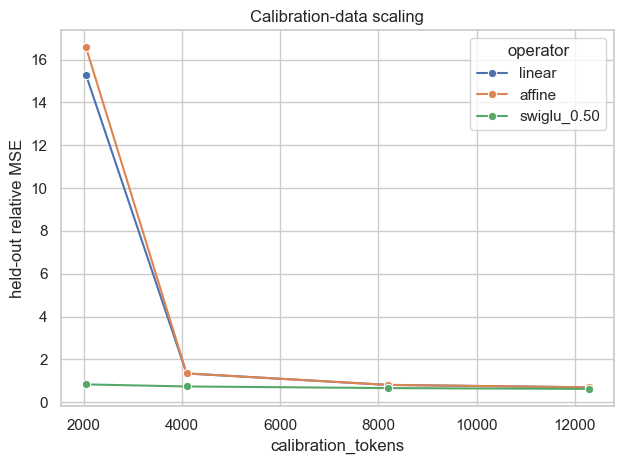

In [49]:
budget_rows = []
history_rows = []
budget_swiglu_modules = {}
fixed_width = (
    round(0.5 * original_intermediate_width)
    if RUN_FROM_SCRATCH else None
)

for num_batches in (
    CALIBRATION_BUDGETS if RUN_FROM_SCRATCH else []
):
    pairs = calibration_prefix(num_batches)
    linear = fit_ridge_linear(
        pairs, ridge=LINEAR_RIDGE, bias=False, device=device
    )
    affine = fit_ridge_linear(
        pairs, ridge=LINEAR_RIDGE, bias=True, device=device
    )
    torch.manual_seed(SEED)
    swiglu_fit = fit_operator(
        GatedMLPReplacement(hidden_size, fixed_width, bias=False),
        pairs,
        validation_pairs,
        training_config,
        device,
    )
    steps_per_epoch = ceil(
        pairs.num_tokens / training_config.batch_size
    )
    budget_swiglu_modules[pairs.num_tokens] = deepcopy(
        swiglu_fit.module
    ).to('cpu')
    for epoch in swiglu_fit.history:
        history_rows.append({
            'calibration_batches': num_batches,
            'calibration_tokens': pairs.num_tokens,
            'epoch': epoch.epoch,
            'optimizer_steps': epoch.epoch * steps_per_epoch,
            'train_mse': epoch.train_mse,
            'validation_mse': epoch.validation_mse,
        })

    for name, module, fit in [
        ('linear', linear, None),
        ('affine', affine, None),
        ('swiglu_0.50', swiglu_fit.module, swiglu_fit),
    ]:
        row = local_row(name, module, pairs, fit)
        integrated = model_metrics(module)
        row.update({
            'loss': integrated.loss,
            'perplexity': integrated.perplexity,
            'delta_loss': integrated.loss - baseline_lm.loss,
            'delta_perplexity': (
                integrated.perplexity - baseline_lm.perplexity
            ),
        })
        row['calibration_batches'] = num_batches
        budget_rows.append(row)

if RUN_FROM_SCRATCH:
    budget_df = pd.DataFrame(budget_rows)
    history_df = pd.DataFrame(history_rows)
else:
    calibration_results = loaded_artifact['results'][
        'calibration_scaling'
    ]
    budget_df = pd.DataFrame(calibration_results['summary'])
    history_df = pd.DataFrame(
        calibration_results['training_history']
    )
ax = sns.lineplot(
    data=budget_df,
    x='calibration_tokens',
    y='local_relative_mse',
    hue='operator',
    marker='o',
)
ax.set(
    title='Calibration-data scaling',
    ylabel='held-out relative MSE',
)
plt.tight_layout()
budget_df

separated plots for linear an swiGLU

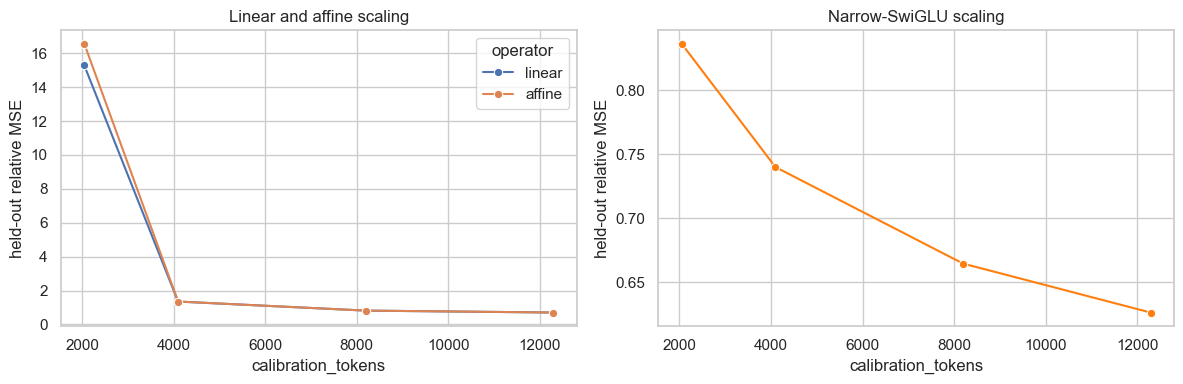

In [50]:
linear_budget_df = budget_df[
    budget_df['operator'].isin(['linear', 'affine'])
]
swiglu_budget_df = budget_df[
    budget_df['operator'] == 'swiglu_0.50'
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(
    data=linear_budget_df,
    x='calibration_tokens',
    y='local_relative_mse',
    hue='operator',
    marker='o',
    ax=axes[0],
)
sns.lineplot(
    data=swiglu_budget_df,
    x='calibration_tokens',
    y='local_relative_mse',
    marker='o',
    color='tab:orange',
    ax=axes[1],
)
axes[0].set(
    title='Linear and affine scaling',
    ylabel='held-out relative MSE',
)
axes[1].set(
    title='Narrow-SwiGLU scaling',
    ylabel='held-out relative MSE',
)
plt.tight_layout()

SwiGLU training and validation histories by calibration budget.

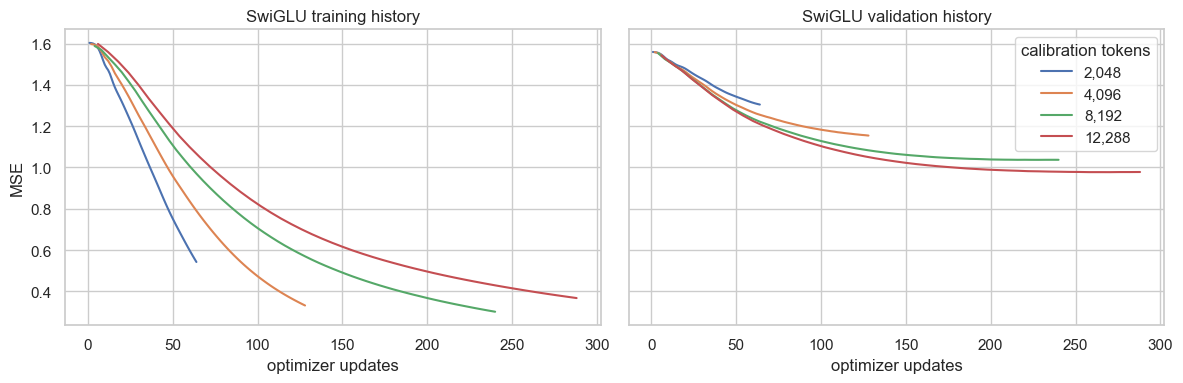

In [51]:
history_plot_df = history_df.copy()
history_plot_df['calibration_budget'] = history_plot_df[
    'calibration_tokens'
].map(lambda value: f'{value:,}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.lineplot(
    data=history_plot_df,
    x='optimizer_steps',
    y='train_mse',
    hue='calibration_budget',
    legend=False,
    ax=axes[0],
)
sns.lineplot(
    data=history_plot_df,
    x='optimizer_steps',
    y='validation_mse',
    hue='calibration_budget',
    ax=axes[1],
)
axes[0].set(
    title='SwiGLU training history',
    xlabel='optimizer updates',
    ylabel='MSE',
)
axes[1].set(
    title='SwiGLU validation history',
    xlabel='optimizer updates',
    ylabel='MSE',
)
axes[1].legend(title='calibration tokens')
plt.tight_layout()

Model-wide validation impact by calibration budget.

,operator,calibration_batches,calibration_tokens,loss,delta_loss,perplexity,delta_perplexity
1,affine,8,2048,4.593343,1.923370,98.824280,84.384694
0,linear,8,2048,4.441403,1.771430,84.894001,70.454416
2,swiglu_0.50,8,2048,2.730558,0.060584,15.341441,0.901855
4,affine,16,4096,2.786200,0.116227,16.219277,1.779691
3,linear,16,4096,2.787512,0.117538,16.240557,1.800972
5,swiglu_0.50,16,4096,2.722960,0.052987,15.225325,0.785739
7,affine,32,8192,2.738249,0.068276,15.459895,1.020309
6,linear,32,8192,2.738213,0.068240,15.459340,1.019754
8,swiglu_0.50,32,8192,2.720240,0.050266,15.183963,0.744377
10,affine,48,12288,2.726351,0.056378,15.277043,0.837457


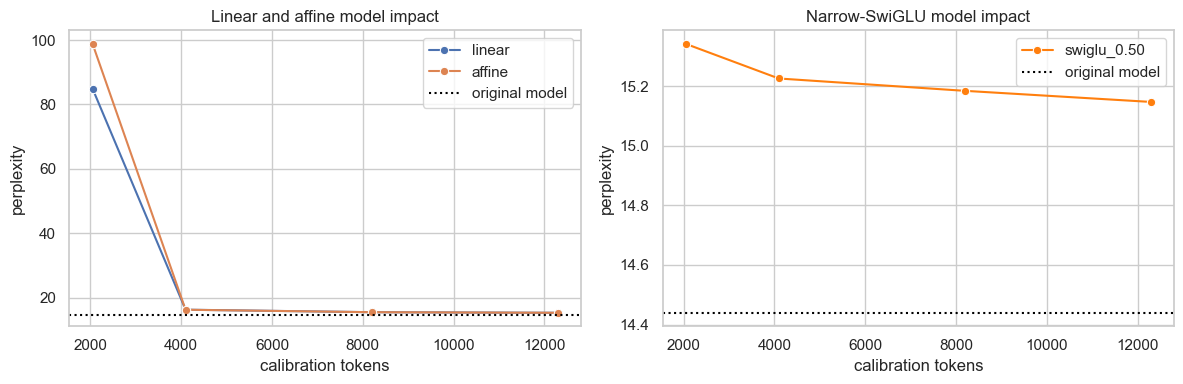

In [52]:
model_budget_df = budget_df[[
    'operator',
    'calibration_batches',
    'calibration_tokens',
    'loss',
    'delta_loss',
    'perplexity',
    'delta_perplexity',
]].sort_values(['calibration_tokens', 'operator'])
display(model_budget_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(
    data=linear_budget_df,
    x='calibration_tokens',
    y='perplexity',
    hue='operator',
    marker='o',
    ax=axes[0],
)
sns.lineplot(
    data=swiglu_budget_df,
    x='calibration_tokens',
    y='perplexity',
    marker='o',
    color='tab:orange',
    label='swiglu_0.50',
    ax=axes[1],
)
for axis in axes:
    axis.axhline(
        baseline_lm.perplexity,
        color='black',
        linestyle=':',
        label='original model',
    )
    axis.set(xlabel='calibration tokens', ylabel='perplexity')
    axis.legend()
axes[0].set_title('Linear and affine model impact')
axes[1].set_title('Narrow-SwiGLU model impact')
plt.tight_layout()

### swiGLU analysis

- Compare reduced-width SwiGLU operators against the maximum-budget linear and affine references using local error and model ppl

,operator,calibration_tokens,parameters,local_mse,local_relative_mse,local_cosine,best_epoch,optimizer_steps,loss,perplexity,delta_loss,delta_perplexity,calibration_batches,width_ratio,intermediate_width,relative_block_parameters
0,swiglu_0.25,12288,12582912,1.009542,0.647126,0.600186,50,318,2.717289,15.139226,0.047316,0.699640,NaN,0.25,2048,0.250000
1,swiglu_0.50,12288,25165824,0.977388,0.626515,0.616383,45,288,2.717785,15.146728,0.047811,0.707142,48.0,0.50,4096,0.500000
2,swiglu_0.75,12288,37748736,0.958872,0.614646,0.625006,41,264,2.719236,15.168725,0.049262,0.729140,NaN,0.75,6144,0.750000
3,swiglu_0.90,12288,45299712,0.951164,0.609705,0.628885,40,258,2.718934,15.164152,0.048961,0.724567,NaN,0.90,7373,0.900024


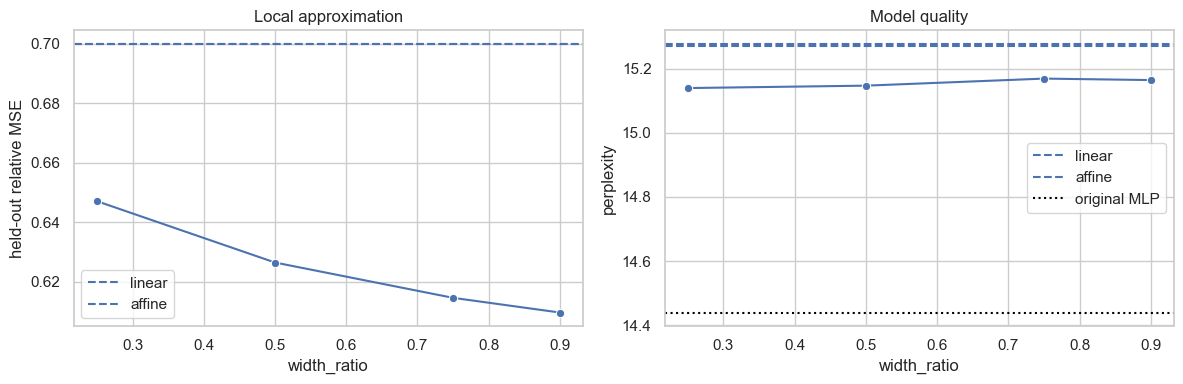

In [53]:
full_pairs = (
    calibration_prefix(MAX_CALIBRATION_BATCHES)
    if RUN_FROM_SCRATCH else None
)
max_budget_df = budget_df[
    budget_df['calibration_batches'] == MAX_CALIBRATION_BATCHES
]
reference_df = max_budget_df[
    max_budget_df['operator'].isin(['linear', 'affine'])
].copy()
reference_rows = reference_df.to_dict(orient='records')

half_width_row = max_budget_df[
    max_budget_df['operator'] == 'swiglu_0.50'
].iloc[0].to_dict()
if RUN_FROM_SCRATCH:
    half_width_row.update({
        'width_ratio': 0.50,
        'intermediate_width': round(
            0.50 * original_intermediate_width
        ),
        'relative_block_parameters': (
            half_width_row['parameters'] / original_parameters
        ),
    })
width_rows = [half_width_row] if RUN_FROM_SCRATCH else []
width_modules = (
    {0.50: swiglu_fit.module} if RUN_FROM_SCRATCH else {}
)

for ratio in (
    SWIGLU_WIDTH_RATIOS if RUN_FROM_SCRATCH else []
):
    if ratio == 0.50:
        continue
    width = max(1, round(ratio * original_intermediate_width))
    torch.manual_seed(SEED)
    fit = fit_operator(
        GatedMLPReplacement(hidden_size, width, bias=False),
        full_pairs,
        validation_pairs,
        training_config,
        device,
    )
    row = local_row(f'swiglu_{ratio:.2f}', fit.module, full_pairs, fit)
    integrated = model_metrics(fit.module)
    width_modules[ratio] = fit.module
    row.update({
        'width_ratio': ratio,
        'intermediate_width': width,
        'relative_block_parameters': (
            count_parameters(fit.module) / original_parameters
        ),
        'loss': integrated.loss,
        'delta_loss': integrated.loss - baseline_lm.loss,
        'perplexity': integrated.perplexity,
        'delta_perplexity': (
            integrated.perplexity - baseline_lm.perplexity
        ),
    })
    width_rows.append(row)

if RUN_FROM_SCRATCH:
    width_df = (
        pd.DataFrame(width_rows)
        .sort_values('width_ratio')
        .reset_index(drop=True)
    )
else:
    width_df = pd.DataFrame(
        loaded_artifact['results']['swiglu_width_scaling']
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(
    data=width_df,
    x='width_ratio',
    y='local_relative_mse',
    marker='o',
    ax=axes[0],
)
sns.lineplot(
    data=width_df,
    x='width_ratio',
    y='perplexity',
    marker='o',
    ax=axes[1],
)
for reference in reference_df.itertuples():
    axes[0].axhline(
        reference.local_relative_mse,
        linestyle='--',
        label=reference.operator,
    )
    axes[1].axhline(
        reference.perplexity,
        linestyle='--',
        label=reference.operator,
    )
axes[1].axhline(
    baseline_lm.perplexity,
    color='black',
    linestyle=':',
    label='original MLP',
)
axes[0].set(title='Local approximation', ylabel='held-out relative MSE')
axes[1].set(title='Model quality', ylabel='perplexity')
for axis in axes:
    axis.legend()
plt.tight_layout()
width_df

#### Recovery across SwiGLU widths

Each width follows one cumulative teacher-logit recovery trajectory. One cached C4 batch equals one optimizer update, and only the replacement operator is trainable.

In [54]:
def recover_trajectories_streaming(
    modules, key_name, initial_df
):
    recovered_modules = {
        key: deepcopy(module).to(device)
        for key, module in modules.items()
    }
    rows = []
    checkpoints = set(RECOVERY_UPDATE_BUDGETS[1:])
    maximum_updates = max(RECOVERY_UPDATE_BUDGETS)
    teacher_dtype = getattr(torch, recovery_config.cache_dtype)

    original_flags = [
        (parameter, parameter.requires_grad)
        for parameter in model.parameters()
    ]
    for parameter, _ in original_flags:
        parameter.requires_grad = False

    optimizers = {}
    for key, module in recovered_modules.items():
        for parameter in module.parameters():
            parameter.requires_grad = True
        optimizers[key] = torch.optim.AdamW(
            module.parameters(),
            lr=recovery_config.learning_rate,
            weight_decay=recovery_config.weight_decay,
        )
        pre_recovery = initial_df.loc[
            initial_df[key_name] == key
        ].iloc[0]
        rows.append({
            key_name: key,
            'recovery_updates': 0,
            'recovery_tokens': 0,
            'loss': pre_recovery['loss'],
            'perplexity': pre_recovery['perplexity'],
            'delta_loss': pre_recovery['delta_loss'],
            'delta_perplexity': pre_recovery['delta_perplexity'],
        })

    completed_updates = 0
    try:
        model.eval()
        for update, batch in enumerate(loaders.recovery, start=1):
            if update > maximum_updates:
                break
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            with torch.no_grad():
                teacher_logits = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                ).logits.detach().to(dtype=teacher_dtype)
            teacher_batch = TeacherBatch(
                input_ids=input_ids,
                attention_mask=attention_mask,
                logits=teacher_logits,
            )

            for key, module in recovered_modules.items():
                module.train()
                with temporary_replacement(
                    model, TARGET_LAYER, module
                ):
                    loss = distillation_loss(
                        model,
                        teacher_batch,
                        recovery_config.temperature,
                        device,
                    )
                    optimizers[key].zero_grad(set_to_none=True)
                    loss.backward()
                    optimizers[key].step()

            del teacher_batch, teacher_logits
            completed_updates = update
            if update in checkpoints:
                for key, module in recovered_modules.items():
                    module.eval()
                    with temporary_replacement(
                        model, TARGET_LAYER, module
                    ):
                        metrics = evaluate_language_model(
                            model,
                            loaders.model_validation,
                            device,
                            data_config.num_model_validation_batches,
                        )
                    rows.append({
                        key_name: key,
                        'recovery_updates': update,
                        'recovery_tokens': (
                            update
                            * data_config.batch_size
                            * data_config.sequence_length
                        ),
                        'loss': metrics.loss,
                        'perplexity': metrics.perplexity,
                        'delta_loss': metrics.loss - baseline_lm.loss,
                        'delta_perplexity': (
                            metrics.perplexity - baseline_lm.perplexity
                        ),
                    })
                    print(
                        f'{key_name}={key}, '
                        f'updates={update}, ppl={metrics.perplexity:.4f}'
                    )

        if completed_updates < maximum_updates:
            raise RuntimeError(
                f'Recovery loader provided only {completed_updates} '
                f'of {maximum_updates} required batches'
            )
    finally:
        for module in recovered_modules.values():
            module.eval()
        for parameter, requires_grad in original_flags:
            parameter.requires_grad = requires_grad

    return rows, recovered_modules

In [55]:
if RUN_FROM_SCRATCH:
    print(
        f'Streaming {max(RECOVERY_UPDATE_BUDGETS)} teacher batches...'
    )
    recovery_rows, recovered_width_modules = (
        recover_trajectories_streaming(
            width_modules, 'width_ratio', width_df
        )
    )
else:
    recovery_rows = loaded_artifact['results']['recovery']
recovery_df = (
    pd.DataFrame(recovery_rows)
    .sort_values(['width_ratio', 'recovery_updates'])
    .reset_index(drop=True)
)
recovery_df

,width_ratio,recovery_updates,recovery_tokens,loss,perplexity,delta_loss,delta_perplexity
0,0.25,0,0,2.717289,15.139226,0.047316,0.699640
1,0.25,64,16384,2.717050,15.135603,0.047076,0.696017
2,0.25,128,32768,2.716094,15.121151,0.046121,0.681565
3,0.25,256,65536,2.716615,15.129025,0.046642,0.689439
4,0.25,512,131072,2.715920,15.118505,0.045946,0.678920
5,0.25,1024,262144,2.715813,15.116899,0.045840,0.677313
6,0.50,0,0,2.717785,15.146728,0.047811,0.707142
7,0.50,64,16384,2.717524,15.142776,0.047550,0.703190
8,0.50,128,32768,2.716806,15.131915,0.046833,0.692329
9,0.50,256,65536,2.717398,15.140868,0.047424,0.701282


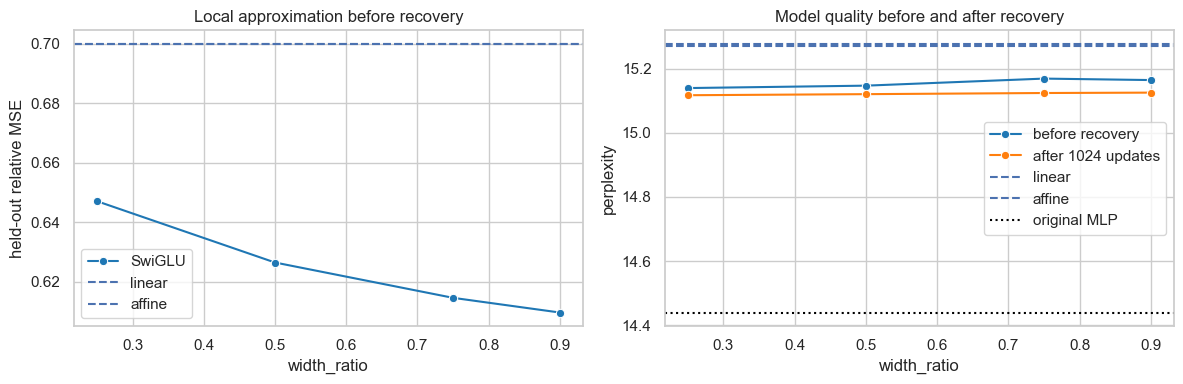

In [56]:
final_recovery_update = max(RECOVERY_UPDATE_BUDGETS)
quality_df = pd.concat([
    width_df[['width_ratio', 'perplexity']].assign(
        recovery='before recovery'
    ),
    recovery_df[
        recovery_df['recovery_updates'] == final_recovery_update
    ][['width_ratio', 'perplexity']].assign(
        recovery=f'after {final_recovery_update} updates'
    ),
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(
    data=width_df,
    x='width_ratio',
    y='local_relative_mse',
    marker='o',
    color='tab:blue',
    label='SwiGLU',
    ax=axes[0],
)
sns.lineplot(
    data=quality_df,
    x='width_ratio',
    y='perplexity',
    hue='recovery',
    marker='o',
    palette={
        'before recovery': 'tab:blue',
        f'after {final_recovery_update} updates': 'tab:orange',
    },
    ax=axes[1],
)
for reference in reference_df.itertuples():
    axes[0].axhline(
        reference.local_relative_mse,
        linestyle='--',
        label=reference.operator,
    )
    axes[1].axhline(
        reference.perplexity,
        linestyle='--',
        label=reference.operator,
    )
axes[1].axhline(
    baseline_lm.perplexity,
    color='black',
    linestyle=':',
    label='original MLP',
)
axes[0].set(
    title='Local approximation before recovery',
    ylabel='held-out relative MSE',
)
axes[1].set(
    title='Model quality before and after recovery',
    ylabel='perplexity',
)
for axis in axes:
    axis.legend()
plt.tight_layout()

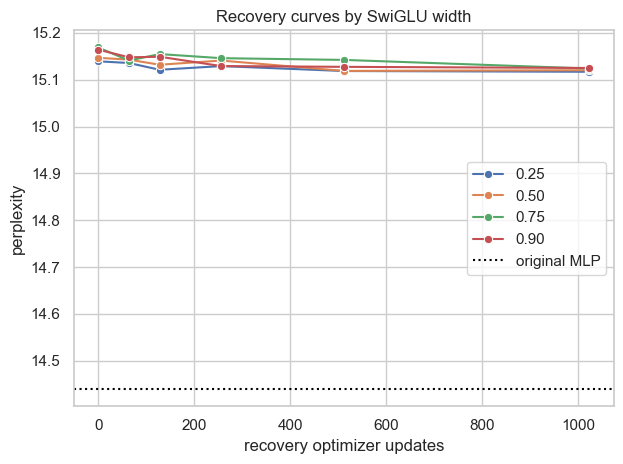

In [57]:
recovery_plot_df = recovery_df.copy()
recovery_plot_df['width'] = recovery_plot_df['width_ratio'].map(
    lambda ratio: f'{ratio:.2f}'
)
ax = sns.lineplot(
    data=recovery_plot_df,
    x='recovery_updates',
    y='perplexity',
    hue='width',
    marker='o',
)
ax.axhline(
    baseline_lm.perplexity,
    color='black',
    linestyle=':',
    label='original MLP',
)
ax.set(
    title='Recovery curves by SwiGLU width',
    xlabel='recovery optimizer updates',
    ylabel='perplexity',
)
ax.legend()
plt.tight_layout()

#### SwiGLU width and recovery summary

Summarizes footprint, local fit, and final recovered model quality for the baseline widths.

In [58]:
final_recovery_df = (
    recovery_df.loc[
        recovery_df['recovery_updates'] == final_recovery_update,
        ['width_ratio', 'perplexity', 'delta_perplexity'],
    ]
    .rename(columns={
        'perplexity': 'recovered_perplexity',
        'delta_perplexity': 'recovered_delta_perplexity',
    })
)
width_recovery_table = (
    width_df.loc[
        width_df['width_ratio'].isin([0.25, 0.50, 0.75])
    ]
    .merge(final_recovery_df, on='width_ratio', validate='one_to_one')
    .assign(
        retained_parameters_pct=lambda frame: (
            100 * frame['relative_block_parameters']
        )
    )[[
        'width_ratio',
        'intermediate_width',
        'parameters',
        'retained_parameters_pct',
        'calibration_tokens',
        'local_relative_mse',
        'perplexity',
        'recovered_perplexity',
        'recovered_delta_perplexity',
    ]]
    .sort_values('width_ratio')
    .reset_index(drop=True)
)
width_recovery_table.style.format({
    'width_ratio': '{:.2f}',
    'parameters': '{:,.0f}',
    'retained_parameters_pct': '{:.2f}%',
    'calibration_tokens': '{:,.0f}',
    'local_relative_mse': '{:.4f}',
    'perplexity': '{:.4f}',
    'recovered_perplexity': '{:.4f}',
    'recovered_delta_perplexity': '{:+.4f}',
})

,width_ratio,intermediate_width,parameters,retained_parameters_pct,calibration_tokens,local_relative_mse,perplexity,recovered_perplexity,recovered_delta_perplexity
0,0.25,2048,"12,582,912",25.00%,"12,288",0.6471,15.1392,15.1169,+0.6773
1,0.50,4096,"25,165,824",50.00%,"12,288",0.6265,15.1467,15.1202,+0.6806
2,0.75,6144,"37,748,736",75.00%,"12,288",0.6146,15.1687,15.1238,+0.6842


___

## Multi-block Experiments

working with multiple blocks

### Block comparison

- comparison of differen block behaviour on baselines (e.g. validation loss across layers=[3, 11, 19])
- maybe 3D surface plots (calibration, retraining) -> ppl, compare block diffs
- testing KL divergence curve: map KL loss to each block before retraining and see distribution diff (visualization using the distribution plot)

In [59]:
TARGET_LAYERS = (
    [3, 11, 19]
    if RUN_FROM_SCRATCH
    else loaded_artifact['configuration']['target_layers']
)

#### Calibration / Validation

- testing calibration/validation data size impact

#### Retraining validation
- compare compressed model perplexity/other loss

#### KL divergence analysis

- scope: TARGET_LAYERS (e.g. 3, 11, 19) or full model (all layers)
- scope: tests single block replacement impact
- out of scope: does not test block replacement interactions (e.g. K_ij = K_i + K_j)

1. KL divergence curve degradation analysis:

    - assign: $KL_i$ per layer
    - measure: curvature
    - compare: different curvatures across tested operators (e.g. linear vs swiGLU, swiGLU widths...)
    - ideas:
        - 3D surface plot [block_layer, operator class] -> KL_div

2. KL divergence curve retraining impact:

    - assign: $KL_i$ per layer
    - measure: curvature
    - hue: before retraining vs after retraining, allows us to see repairability of blocks
    - ideas:
        - 3D surface plot [block_layer, operator class] -> KL_div

3. Global-to-Local ratio:
    - assign: $R_i = K_i^{pre} / (E_i^{local} + \epsilon)$
    - high R: small local error causes big model error
    - low R: model tolerates high local error
    - ideas:
        - R-curve similiar to above plots
        - single-block operator comparison
        - 3D surface plot [block_layer, operator class] -> R
    - plots:
        - local-MSE-L2 to KL-div scatterplot
        - x-axis: local-MSE L2
        - y-axis: KL-div
        - hue: operator class (shape), color operator width (swiGLU, MLP)

4. Single block replaceability profile:
    - x axis: selected operator
    - y axis: KL-div (pre)
    - useful for testing swiGLU widths (continuity), comparing operators


5. p_T(s) vs p_S(s) distribution visualization plot:
    - x axis: distributions
    - y axis: layer index
    - y axis: secondary values KL_div(p_t, p_s)

$$
E_i^{\mathrm{local}}
=
\frac{
\mathbb{E}
\left[
\left\|g_i(h_i)-f_i(h_i)\right\|_2^2
\right]
}{
\mathbb{E}
\left[
\left\|f_i(h_i)\right\|_2^2
\right]
+\varepsilon
}
$$

$$
K_i^{\mathrm{pre}}
=
\mathbb{E}
\left[
D_{\mathrm{KL}}
\left(
p_T(\cdot \mid x)
\parallel
p_{S_i}(\cdot \mid x)
\right)
\right]
$$

implementation

1.

,layer,operator,kl_divergence
2,3,affine,0.153434
10,11,affine,0.055024
18,19,affine,0.225134
24,3,linear,0.153453
32,11,linear,0.055091
40,19,linear,0.224604
46,3,swiglu_0.25,0.111596
54,11,swiglu_0.25,0.042808
62,19,swiglu_0.25,0.172310
68,3,swiglu_0.50,0.109884


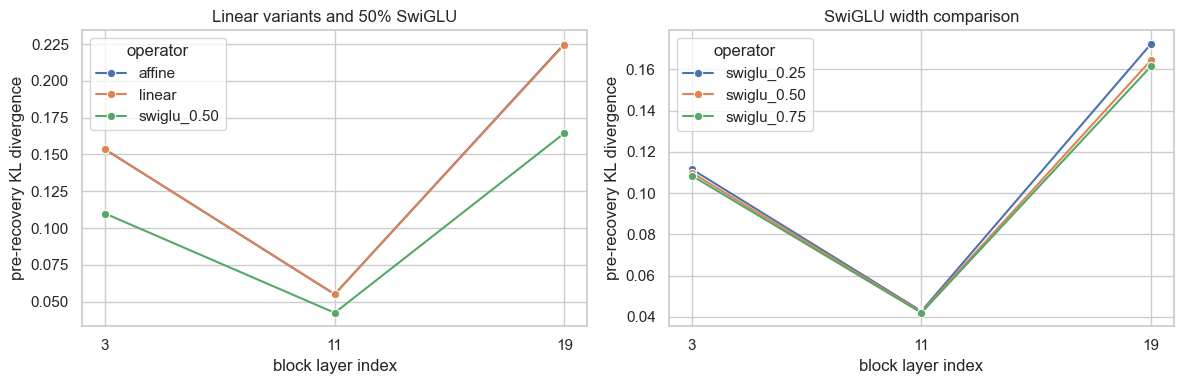

In [60]:
KL_WIDTH_RATIOS = (
    [0.25, 0.50, 0.75]
    if RUN_FROM_SCRATCH
    else loaded_artifact['configuration']['kl_width_ratios']
)

def cached_model_kl(layer_index, module, teacher_cache):
    losses = []
    with temporary_replacement(model, layer_index, module):
        model.eval()
        with torch.no_grad():
            for batch in teacher_cache.batches:
                losses.append(float(distillation_loss(
                    model, batch, recovery_config.temperature, device
                ).item()))
    return sum(losses) / len(losses)


if RUN_FROM_SCRATCH:
    kl_teacher_cache = cache_teacher_logits(
        model,
        loaders.model_validation,
        data_config.num_model_validation_batches,
        device,
        recovery_config.cache_dtype,
    )

kl_rows = []
kl_candidate_modules = {}
for layer_index in (TARGET_LAYERS if RUN_FROM_SCRATCH else []):
    layer_block = get_mlp_block(model, layer_index)
    layer_training_pairs = collect_module_io(
        model,
        layer_block.path,
        loaders.calibration,
        MAX_CALIBRATION_BATCHES,
        **capture_kwargs,
    )
    layer_validation_pairs = collect_module_io(
        model,
        layer_block.path,
        loaders.operator_validation,
        data_config.num_operator_validation_batches,
        **capture_kwargs,
    )
    layer_hidden_size = layer_training_pairs.hidden_size
    layer_intermediate_width = int(
        layer_block.module.up_proj.out_features
    )

    candidates = {
        'linear': fit_ridge_linear(
            layer_training_pairs,
            ridge=LINEAR_RIDGE,
            bias=False,
            device=device,
        ),
        'affine': fit_ridge_linear(
            layer_training_pairs,
            ridge=LINEAR_RIDGE,
            bias=True,
            device=device,
        ),
    }
    for ratio in KL_WIDTH_RATIOS:
        width = max(1, round(ratio * layer_intermediate_width))
        torch.manual_seed(SEED)
        fitted = fit_operator(
            GatedMLPReplacement(
                layer_hidden_size, width, bias=False
            ),
            layer_training_pairs,
            layer_validation_pairs,
            training_config,
            device,
        )
        candidates[f'swiglu_{ratio:.2f}'] = fitted.module

    for operator, module in candidates.items():
        kl_value = cached_model_kl(
            layer_index, module, kl_teacher_cache
        )
        kl_rows.append({
            'layer': layer_index,
            'operator': operator,
            'kl_divergence': kl_value,
        })
        kl_candidate_modules[(layer_index, operator)] = module.to('cpu')

if RUN_FROM_SCRATCH:
    kl_df = pd.DataFrame(kl_rows).sort_values([
        'operator', 'layer'
    ])
else:
    loaded_full_kl_df = pd.DataFrame(
        loaded_artifact['results']['kl_divergence']['full_depth']
    )
    kl_df = loaded_full_kl_df[
        loaded_full_kl_df['layer'].isin(TARGET_LAYERS)
    ].copy()

linear_comparison = kl_df[
    kl_df['operator'].isin(['linear', 'affine', 'swiglu_0.50'])
]
width_comparison = kl_df[
    kl_df['operator'].isin([
        'swiglu_0.25', 'swiglu_0.50', 'swiglu_0.75'
    ])
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(
    data=linear_comparison,
    x='layer',
    y='kl_divergence',
    hue='operator',
    marker='o',
    ax=axes[0],
)
sns.lineplot(
    data=width_comparison,
    x='layer',
    y='kl_divergence',
    hue='operator',
    marker='o',
    ax=axes[1],
)
axes[0].set_title('Linear variants and 50% SwiGLU')
axes[1].set_title('SwiGLU width comparison')
for axis in axes:
    axis.set(
        xlabel='block layer index',
        ylabel='pre-recovery KL divergence',
        xticks=TARGET_LAYERS,
    )
plt.tight_layout()
kl_df

,layer,operator,kl_divergence
0,1,affine,4.075284
1,2,affine,0.215902
2,3,affine,0.153434
3,4,affine,0.129222
4,5,affine,0.117668
...,...,...,...
105,18,swiglu_0.75,0.123715
106,19,swiglu_0.75,0.161471
107,20,swiglu_0.75,0.160869
108,21,swiglu_0.75,0.154624


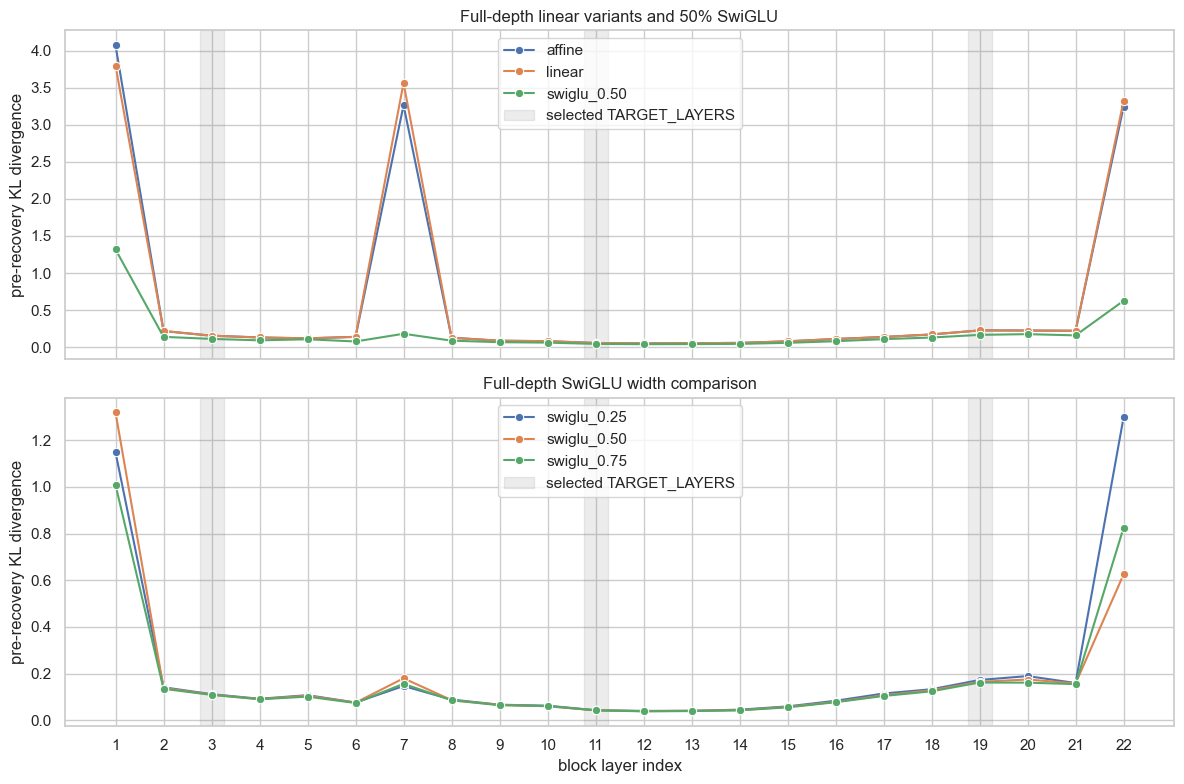

In [61]:
if RUN_FROM_SCRATCH:
    all_layer_indices = list(range(
        int(model.config.num_hidden_layers)
    ))
    eligible_layer_indices = all_layer_indices[1:-1]
else:
    eligible_layer_indices = sorted(
        loaded_full_kl_df['layer'].astype(int).unique().tolist()
    )
    excluded_layer_indices = loaded_artifact[
        'configuration'
    ]['excluded_layers']
    all_layer_indices = sorted(
        eligible_layer_indices + excluded_layer_indices
    )
remaining_layer_indices = [
    index for index in eligible_layer_indices
    if RUN_FROM_SCRATCH and index not in TARGET_LAYERS
]
remaining_blocks = [
    get_mlp_block(model, index) for index in remaining_layer_indices
]
remaining_paths = [block.path for block in remaining_blocks]

remaining_training_pairs = (
    collect_modules_io(
        model,
        remaining_paths,
        loaders.calibration,
        MAX_CALIBRATION_BATCHES,
        **capture_kwargs,
    ) if RUN_FROM_SCRATCH else {}
)
remaining_validation_pairs = (
    collect_modules_io(
        model,
        remaining_paths,
        loaders.operator_validation,
        data_config.num_operator_validation_batches,
        **capture_kwargs,
    ) if RUN_FROM_SCRATCH else {}
)

full_kl_rows = kl_df.to_dict(orient='records')
full_kl_candidate_modules = dict(kl_candidate_modules)

for layer_block in remaining_blocks:
    layer_index = layer_block.index
    layer_training_pairs = remaining_training_pairs[layer_block.path]
    layer_validation_pairs = remaining_validation_pairs[layer_block.path]
    layer_hidden_size = layer_training_pairs.hidden_size
    layer_intermediate_width = int(
        layer_block.module.up_proj.out_features
    )

    candidates = {
        'linear': fit_ridge_linear(
            layer_training_pairs,
            ridge=LINEAR_RIDGE,
            bias=False,
            device=device,
        ),
        'affine': fit_ridge_linear(
            layer_training_pairs,
            ridge=LINEAR_RIDGE,
            bias=True,
            device=device,
        ),
    }
    for ratio in KL_WIDTH_RATIOS:
        width = max(1, round(ratio * layer_intermediate_width))
        torch.manual_seed(SEED)
        fitted = fit_operator(
            GatedMLPReplacement(
                layer_hidden_size, width, bias=False
            ),
            layer_training_pairs,
            layer_validation_pairs,
            training_config,
            device,
        )
        candidates[f'swiglu_{ratio:.2f}'] = fitted.module

    for operator, module in candidates.items():
        kl_value = cached_model_kl(
            layer_index, module, kl_teacher_cache
        )
        full_kl_rows.append({
            'layer': layer_index,
            'operator': operator,
            'kl_divergence': kl_value,
        })
        full_kl_candidate_modules[(
            layer_index, operator
        )] = module.to('cpu')
    print(f'layer {layer_index}: KL sweep complete')

del remaining_training_pairs, remaining_validation_pairs

if RUN_FROM_SCRATCH:
    full_kl_df = (
        pd.DataFrame(full_kl_rows)
        .sort_values(['operator', 'layer'])
        .reset_index(drop=True)
    )
else:
    full_kl_df = loaded_full_kl_df.copy()
full_linear_comparison = full_kl_df[
    full_kl_df['operator'].isin([
        'linear', 'affine', 'swiglu_0.50'
    ])
]
full_width_comparison = full_kl_df[
    full_kl_df['operator'].isin([
        'swiglu_0.25', 'swiglu_0.50', 'swiglu_0.75'
    ])
]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
sns.lineplot(
    data=full_linear_comparison,
    x='layer',
    y='kl_divergence',
    hue='operator',
    marker='o',
    ax=axes[0],
)
sns.lineplot(
    data=full_width_comparison,
    x='layer',
    y='kl_divergence',
    hue='operator',
    marker='o',
    ax=axes[1],
)
for axis in axes:
    for target_position, target_layer in enumerate(TARGET_LAYERS):
        axis.axvspan(
            target_layer - 0.25,
            target_layer + 0.25,
            color='grey',
            alpha=0.15,
            label=(
                'selected TARGET_LAYERS'
                if target_position == 0 else None
            ),
        )
    axis.set(
        ylabel='pre-recovery KL divergence',
        xticks=eligible_layer_indices,
    )
    axis.legend()
axes[0].set_title('Full-depth linear variants and 50% SwiGLU')
axes[1].set(
    title='Full-depth SwiGLU width comparison',
    xlabel='block layer index',
)
plt.tight_layout()
full_kl_df

2.

,layer,operator,pre_recovery_kl,recovery_updates,post_recovery_kl,kl_reduction
0,1,affine,4.075284,64,4.069687,0.005596
1,2,affine,0.215902,64,0.216042,-0.000141
2,3,affine,0.153434,64,0.153515,-0.000080
3,4,affine,0.129222,64,0.129155,0.000068
4,5,affine,0.117668,64,0.117646,0.000022
...,...,...,...,...,...,...
105,18,swiglu_0.75,0.123715,64,0.123175,0.000541
106,19,swiglu_0.75,0.161471,64,0.161124,0.000347
107,20,swiglu_0.75,0.160869,64,0.160737,0.000132
108,21,swiglu_0.75,0.154624,64,0.154480,0.000144


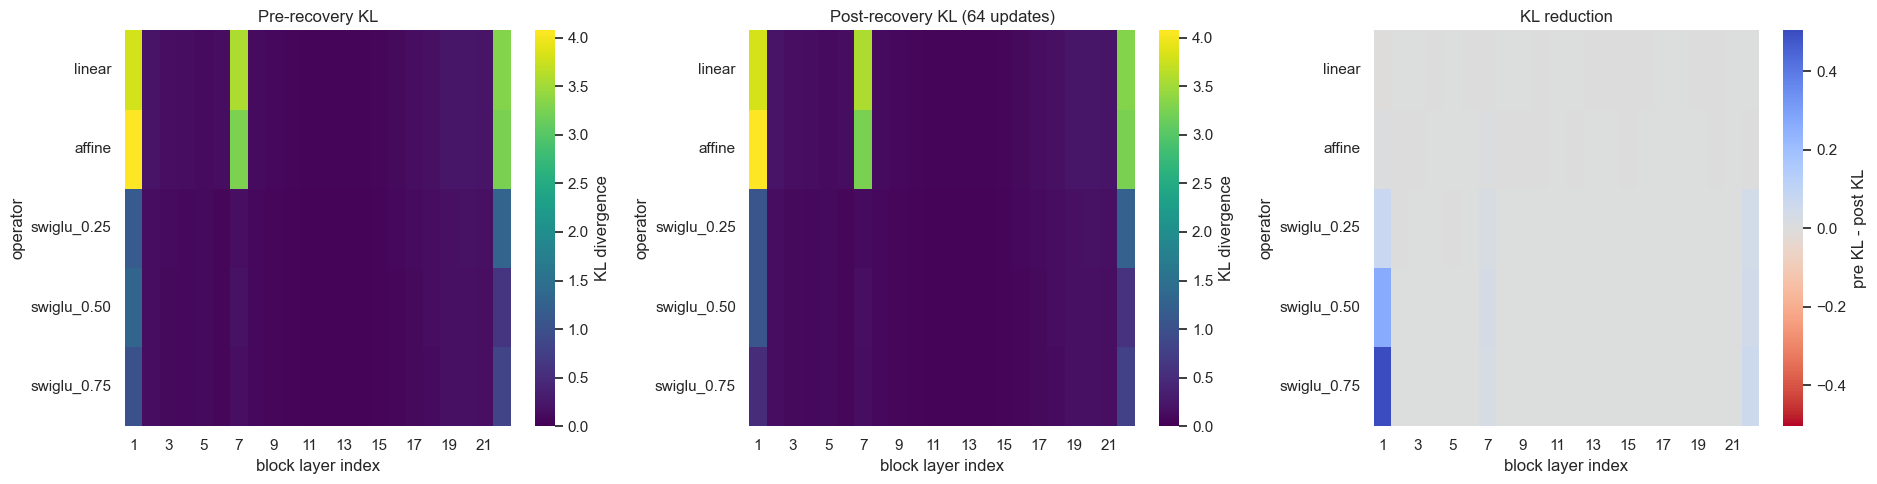

In [62]:
KL_RECOVERY_UPDATE_BUDGET = (
    RECOVERY_UPDATE_BUDGETS[1]
    if RUN_FROM_SCRATCH
    else loaded_artifact['configuration'][
        'kl_recovery_update_budget'
    ]
)
KL_RECOVERY_OPERATORS = (
    [
        'linear',
        'affine',
        'swiglu_0.25',
        'swiglu_0.50',
        'swiglu_0.75',
    ]
    if RUN_FROM_SCRATCH
    else loaded_artifact['configuration'][
        'kl_recovery_operators'
    ]
)

def recover_layer_candidates_streaming(
    layer_index, candidates, update_budget
):
    layer_block = get_mlp_block(model, layer_index)
    reference_parameter = next(layer_block.module.parameters())
    recovered = {
        operator: deepcopy(module).to(
            device=reference_parameter.device,
            dtype=reference_parameter.dtype,
        )
        for operator, module in candidates.items()
    }
    optimizers = {
        operator: torch.optim.AdamW(
            module.parameters(),
            lr=recovery_config.learning_rate,
            weight_decay=recovery_config.weight_decay,
        )
        for operator, module in recovered.items()
    }
    teacher_dtype = getattr(torch, recovery_config.cache_dtype)
    original_flags = [
        (parameter, parameter.requires_grad)
        for parameter in model.parameters()
    ]
    for parameter, _ in original_flags:
        parameter.requires_grad = False
    for module in recovered.values():
        for parameter in module.parameters():
            parameter.requires_grad = True

    completed_updates = 0
    try:
        model.eval()
        for update, batch in enumerate(loaders.recovery, start=1):
            if update > update_budget:
                break
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            with torch.no_grad():
                teacher_logits = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                ).logits.detach().to(dtype=teacher_dtype)
            teacher_batch = TeacherBatch(
                input_ids=input_ids,
                attention_mask=attention_mask,
                logits=teacher_logits,
            )

            for operator, module in recovered.items():
                module.train()
                with temporary_replacement(
                    model, layer_index, module
                ):
                    loss = distillation_loss(
                        model,
                        teacher_batch,
                        recovery_config.temperature,
                        device,
                    )
                    optimizers[operator].zero_grad(
                        set_to_none=True
                    )
                    loss.backward()
                    optimizers[operator].step()

            del teacher_batch, teacher_logits
            completed_updates = update

        if completed_updates < update_budget:
            raise RuntimeError(
                f'Recovery loader provided only {completed_updates} '
                f'of {update_budget} required batches'
            )
    finally:
        for module in recovered.values():
            module.eval()
        for parameter, requires_grad in original_flags:
            parameter.requires_grad = requires_grad

    return recovered


post_kl_rows = []
for layer_index in (
    eligible_layer_indices if RUN_FROM_SCRATCH else []
):
    layer_candidates = {
        operator: full_kl_candidate_modules[(
            layer_index, operator
        )]
        for operator in KL_RECOVERY_OPERATORS
    }
    recovered_candidates = recover_layer_candidates_streaming(
        layer_index,
        layer_candidates,
        KL_RECOVERY_UPDATE_BUDGET,
    )
    for operator, module in recovered_candidates.items():
        post_kl_rows.append({
            'layer': layer_index,
            'operator': operator,
            'recovery_updates': KL_RECOVERY_UPDATE_BUDGET,
            'post_recovery_kl': cached_model_kl(
                layer_index, module, kl_teacher_cache
            ),
        })
        module.to('cpu')
    del recovered_candidates
    print(f'layer {layer_index}: recovery KL complete')

if RUN_FROM_SCRATCH:
    post_kl_df = pd.DataFrame(post_kl_rows)
    pre_kl_df = full_kl_df.rename(columns={
        'kl_divergence': 'pre_recovery_kl'
    })
    kl_recovery_df = pre_kl_df.merge(
        post_kl_df,
        on=['layer', 'operator'],
        validate='one_to_one',
    )
    kl_recovery_df['kl_reduction'] = (
        kl_recovery_df['pre_recovery_kl']
        - kl_recovery_df['post_recovery_kl']
    )
    kl_recovery_df = kl_recovery_df.sort_values(
        ['operator', 'layer']
    ).reset_index(drop=True)
else:
    kl_recovery_df = pd.DataFrame(
        loaded_artifact['results']['kl_divergence'][
            'recovery_impact'
        ]
    )

def recovery_matrix(value):
    return (
        kl_recovery_df.pivot(
            index='operator', columns='layer', values=value
        )
        .reindex(
            index=KL_RECOVERY_OPERATORS,
            columns=eligible_layer_indices,
        )
    )


pre_kl_matrix = recovery_matrix('pre_recovery_kl')
post_kl_matrix = recovery_matrix('post_recovery_kl')
kl_reduction_matrix = recovery_matrix('kl_reduction')
shared_kl_max = max(
    pre_kl_matrix.max().max(),
    post_kl_matrix.max().max(),
)
reduction_limit = max(
    kl_reduction_matrix.abs().max().max(), 1e-12
)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
sns.heatmap(
    pre_kl_matrix,
    cmap='viridis',
    vmin=0,
    vmax=shared_kl_max,
    cbar_kws={'label': 'KL divergence'},
    ax=axes[0],
)
sns.heatmap(
    post_kl_matrix,
    cmap='viridis',
    vmin=0,
    vmax=shared_kl_max,
    cbar_kws={'label': 'KL divergence'},
    ax=axes[1],
)
sns.heatmap(
    kl_reduction_matrix,
    cmap='coolwarm_r',
    vmin=-reduction_limit,
    vmax=reduction_limit,
    center=0,
    cbar_kws={'label': 'pre KL - post KL'},
    ax=axes[2],
)
axes[0].set_title('Pre-recovery KL')
axes[1].set_title(
    f'Post-recovery KL ({KL_RECOVERY_UPDATE_BUDGET} updates)'
)
axes[2].set_title('KL reduction')
for axis in axes:
    axis.set(xlabel='block layer index', ylabel='operator')
plt.tight_layout()
kl_recovery_df

3.

,layer,operator,width_ratio,local_relative_mse,pre_recovery_kl,global_to_local_ratio,ratio_rank_within_operator
2,3,affine,NaN,0.964219,0.153434,0.159128,9
24,3,linear,NaN,0.964267,0.153453,0.159140,9
46,3,swiglu_0.25,0.25,0.742052,0.111596,0.150389,10
68,3,swiglu_0.50,0.50,0.719497,0.109884,0.152724,10
90,3,swiglu_0.75,0.75,0.705177,0.108450,0.153791,10
10,11,affine,NaN,0.763011,0.055024,0.072114,19
32,11,linear,NaN,0.762966,0.055091,0.072206,19
54,11,swiglu_0.25,0.25,0.686696,0.042808,0.062339,20
76,11,swiglu_0.50,0.50,0.667673,0.042429,0.063548,20
98,11,swiglu_0.75,0.75,0.656737,0.042028,0.063995,20


,layer,operator,width_ratio,local_relative_mse,pre_recovery_kl,global_to_local_ratio,ratio_rank_within_operator
0,1,affine,NaN,0.184840,4.075284,22.047667,2
1,2,affine,NaN,0.958857,0.215902,0.225166,5
2,3,affine,NaN,0.964219,0.153434,0.159128,9
3,4,affine,NaN,1.000934,0.129222,0.129102,13
4,5,affine,NaN,1.048561,0.117668,0.112218,15
...,...,...,...,...,...,...,...
105,18,swiglu_0.75,0.75,0.631207,0.123715,0.195998,7
106,19,swiglu_0.75,0.75,0.696486,0.161471,0.231837,4
107,20,swiglu_0.75,0.75,0.753548,0.160869,0.213482,5
108,21,swiglu_0.75,0.75,0.733146,0.154624,0.210905,6


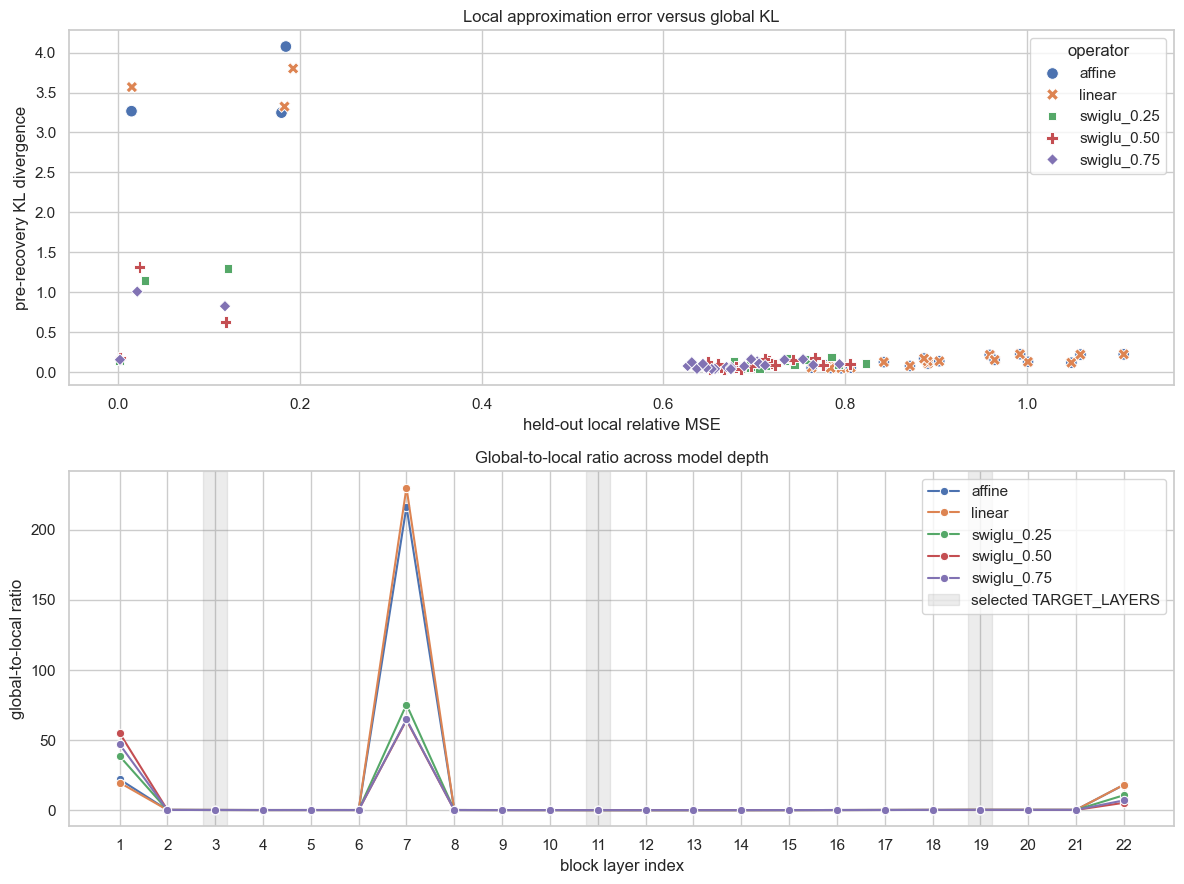

In [63]:
RATIO_EPSILON = (
    1e-8
    if RUN_FROM_SCRATCH
    else loaded_artifact['configuration']['ratio_epsilon']
)

ratio_blocks = (
    {
        index: get_mlp_block(model, index)
        for index in eligible_layer_indices
    } if RUN_FROM_SCRATCH else {}
)
ratio_validation_pairs = (
    collect_modules_io(
        model,
        [block.path for block in ratio_blocks.values()],
        loaders.model_validation,
        data_config.num_model_validation_batches,
        **capture_kwargs,
    ) if RUN_FROM_SCRATCH else {}
)

ratio_rows = []
for row in (
    full_kl_df.itertuples() if RUN_FROM_SCRATCH else []
):
    layer_index = int(row.layer)
    operator = row.operator
    module = full_kl_candidate_modules[(
        layer_index, operator
    )].to(device)
    local_metrics = evaluate_operator(
        module,
        ratio_validation_pairs[ratio_blocks[layer_index].path],
        device,
        training_config.batch_size,
    )
    module.to('cpu')

    local_error = local_metrics.relative_mse
    pre_recovery_kl = float(row.kl_divergence)
    ratio_rows.append({
        'layer': layer_index,
        'operator': operator,
        'width_ratio': (
            float(operator.rsplit('_', 1)[1])
            if operator.startswith('swiglu_') else None
        ),
        'local_relative_mse': local_error,
        'pre_recovery_kl': pre_recovery_kl,
        'global_to_local_ratio': (
            pre_recovery_kl / (local_error + RATIO_EPSILON)
        ),
    })

del ratio_validation_pairs

if RUN_FROM_SCRATCH:
    ratio_df = (
        pd.DataFrame(ratio_rows)
        .sort_values(['operator', 'layer'])
        .reset_index(drop=True)
    )
    ratio_df['ratio_rank_within_operator'] = (
        ratio_df.groupby('operator')['global_to_local_ratio']
        .rank(method='min', ascending=False)
        .astype(int)
    )
else:
    ratio_df = pd.DataFrame(
        loaded_artifact['results']['kl_divergence'][
            'global_to_local'
        ]
    )

selected_ratio_df = ratio_df[
    ratio_df['layer'].isin(TARGET_LAYERS)
][
    [
        'layer',
        'operator',
        'width_ratio',
        'local_relative_mse',
        'pre_recovery_kl',
        'global_to_local_ratio',
        'ratio_rank_within_operator',
    ]
].sort_values(['layer', 'operator'])
display(selected_ratio_df)

fig, axes = plt.subplots(2, 1, figsize=(12, 9))
sns.scatterplot(
    data=ratio_df,
    x='local_relative_mse',
    y='pre_recovery_kl',
    hue='operator',
    style='operator',
    s=70,
    ax=axes[0],
)
sns.lineplot(
    data=ratio_df,
    x='layer',
    y='global_to_local_ratio',
    hue='operator',
    marker='o',
    ax=axes[1],
)
for target_position, target_layer in enumerate(TARGET_LAYERS):
    axes[1].axvspan(
        target_layer - 0.25,
        target_layer + 0.25,
        color='grey',
        alpha=0.15,
        label=(
            'selected TARGET_LAYERS'
            if target_position == 0 else None
        ),
    )
axes[0].set(
    title='Local approximation error versus global KL',
    xlabel='held-out local relative MSE',
    ylabel='pre-recovery KL divergence',
)
axes[1].set(
    title='Global-to-local ratio across model depth',
    xlabel='block layer index',
    ylabel='global-to-local ratio',
    xticks=eligible_layer_indices,
)
axes[1].legend()
plt.tight_layout()
ratio_df

4.

#### Surface plots / heatmaps
These can be 3D surface plots or heatmaps:

1. plot [calibration, retraining] -> PPL/KL_div
2. plot [block_layer, operator class] -> KL_div
3. plot [block_layer, operator class] -> R

In [64]:
if RUN_FROM_SCRATCH:
    max_calibration_tokens = int(
        swiglu_budget_df['calibration_tokens'].max()
    )
    calibration_recovery_modules = {
        tokens: module
        for tokens, module in budget_swiglu_modules.items()
        if tokens != max_calibration_tokens
    }
    calibration_recovery_rows, recovered_budget_modules = (
        recover_trajectories_streaming(
            calibration_recovery_modules,
            'calibration_tokens',
            swiglu_budget_df,
        )
    )
    max_calibration_recovery_df = (
        recovery_df[recovery_df['width_ratio'] == 0.50]
        .drop(columns='width_ratio')
        .assign(calibration_tokens=max_calibration_tokens)
    )
    calibration_recovery_df = pd.concat([
        pd.DataFrame(calibration_recovery_rows),
        max_calibration_recovery_df,
    ], ignore_index=True).sort_values([
        'calibration_tokens', 'recovery_updates'
    ]).reset_index(drop=True)
    for module in recovered_budget_modules.values():
        module.to('cpu')
    del recovered_budget_modules
else:
    calibration_recovery_df = pd.DataFrame(
        loaded_artifact['results']['calibration_recovery']
    )

calibration_recovery_matrix = (
    calibration_recovery_df.pivot(
        index='calibration_tokens',
        columns='recovery_updates',
        values='perplexity',
    )
    .sort_index()
    .reindex(columns=RECOVERY_UPDATE_BUDGETS)
)
ax = sns.heatmap(
    calibration_recovery_matrix,
    cmap='viridis',
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'perplexity'},
)
ax.set(
    title='50% SwiGLU calibration and recovery budget',
    xlabel='recovery optimizer updates',
    ylabel='calibration tokens',
)
plt.tight_layout()

KeyError: 'calibration_recovery'

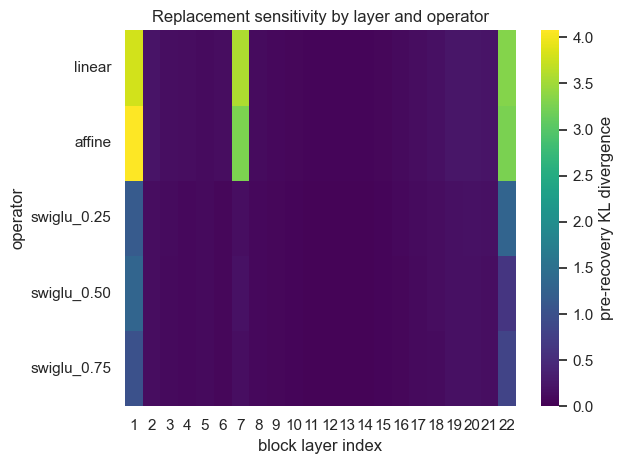

In [65]:
kl_surface_matrix = (
    full_kl_df.pivot(
        index='operator',
        columns='layer',
        values='kl_divergence',
    )
    .reindex(
        index=KL_RECOVERY_OPERATORS,
        columns=eligible_layer_indices,
    )
)
ax = sns.heatmap(
    kl_surface_matrix,
    cmap='viridis',
    vmin=0,
    cbar_kws={'label': 'pre-recovery KL divergence'},
)
ax.set(
    title='Replacement sensitivity by layer and operator',
    xlabel='block layer index',
    ylabel='operator',
)
plt.tight_layout()

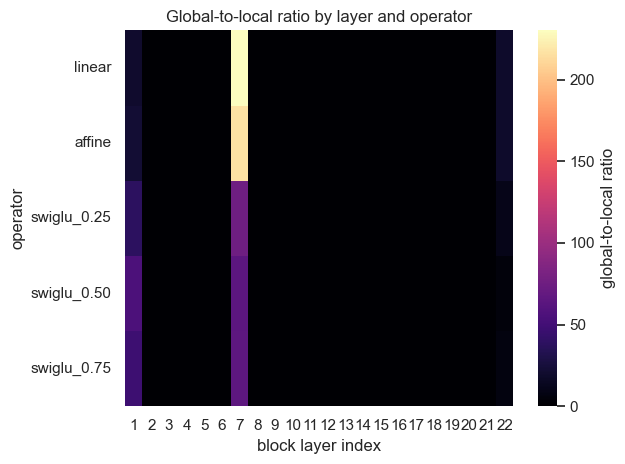

In [66]:
ratio_surface_matrix = (
    ratio_df.pivot(
        index='operator',
        columns='layer',
        values='global_to_local_ratio',
    )
    .reindex(
        index=KL_RECOVERY_OPERATORS,
        columns=eligible_layer_indices,
    )
)
ax = sns.heatmap(
    ratio_surface_matrix,
    cmap='magma',
    vmin=0,
    cbar_kws={'label': 'global-to-local ratio'},
)
ax.set(
    title='Global-to-local ratio by layer and operator',
    xlabel='block layer index',
    ylabel='operator',
)
plt.tight_layout()

### Multi-block interactions
- different notebook (`model/block-interaction.ipynb`)

### Pareto Frontier Baseline

- picking the best baseline in selected trade-off.
- TODO

___

### Artifacts

Saving performed analyses for reuse

In [ ]:
def json_records(frame):
    return json.loads(
        frame.to_json(orient='records', double_precision=15)
    )


artifact = {
    'schema_version': 3,
    'created_at_utc': datetime.now(timezone.utc).isoformat(),
    'configuration': {
        'model': {
            **asdict(model_config),
            'resolved_revision': (
                getattr(model.config, '_commit_hash', None)
                if RUN_FROM_SCRATCH
                else loaded_artifact['configuration']['model'].get(
                    'resolved_revision'
                )
            ),
        },
        'data': asdict(data_config),
        'operator_training': asdict(training_config),
        'recovery': {
            **asdict(recovery_config),
            'teacher_logit_mode': 'batch_streaming',
        },
        'target_layer': TARGET_LAYER,
        'target_layers': list(TARGET_LAYERS),
        'excluded_layers': [
            all_layer_indices[0], all_layer_indices[-1]
        ],
        'calibration_budgets': list(CALIBRATION_BUDGETS),
        'swiglu_width_ratios': list(SWIGLU_WIDTH_RATIOS),
        'recovery_update_budgets': list(
            RECOVERY_UPDATE_BUDGETS
        ),
        'kl_recovery_update_budget': (
            KL_RECOVERY_UPDATE_BUDGET
        ),
        'kl_width_ratios': list(KL_WIDTH_RATIOS),
        'kl_recovery_operators': list(
            KL_RECOVERY_OPERATORS
        ),
        'linear_ridge': LINEAR_RIDGE,
        'ratio_epsilon': RATIO_EPSILON,
    },
    'results': {
        'baseline_language_model': asdict(baseline_lm),
        'calibration_scaling': {
            'summary': json_records(budget_df),
            'training_history': json_records(history_df),
        },
        'swiglu_width_scaling': json_records(width_df),
        'recovery': json_records(recovery_df),
        'calibration_recovery': json_records(
            calibration_recovery_df
        ),
        'kl_divergence': {
            'full_depth': json_records(full_kl_df),
            'recovery_impact': json_records(
                kl_recovery_df
            ),
            'global_to_local': json_records(ratio_df),
        },
    },
}

if RUN_FROM_SCRATCH:
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    OUTPUT_PATH.write_text(
        json.dumps(artifact, indent=2, allow_nan=False),
        encoding='utf-8',
    )
    print(f'Saved baseline-experiments artifact to {OUTPUT_PATH}')
else:
    artifact = loaded_artifact
    print(f'Loaded baseline-experiments artifact from {OUTPUT_PATH}')

Saved baseline-experiments artifact to /home/sgulas/thesis/development/data/results/notebook-block-study/baseline-experiments.json


___